# B1 — Zero-shot VQA với Qwen2-VL-2B-Instruct

**Chiến lược lưu model local:**
- Lần đầu chạy: tải model từ HuggingFace → lưu xuống thư mục `./model_cache/B1_Qwen2VL`
- Các lần sau / demo: load thẳng từ local, **không cần internet, không cần chờ tải lại**

> ✅ Chạy **Cell 1 → Cell 6** theo thứ tự. Nếu đã có model local thì bỏ qua Cell 3.

In [ ]:
# CELL 0 — Mount Google Drive (chạy đầu tiên)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 1 — Cài đặt thư viện
# ============================================================
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate datasets matplotlib qwen-vl-utils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 20.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2 — Import thư viện & cấu hình đường dẫn
# ============================================================
import os
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset
import matplotlib.pyplot as plt
from qwen_vl_utils import process_vision_info

# --- CẤU HÌNH ĐƯỜNG DẪN ---
# Thay đổi LOCAL_MODEL_DIR nếu bạn muốn lưu ở chỗ khác
# Ví dụ Google Drive: "/content/drive/MyDrive/B1_checkpoint/Qwen2VL"
#LOCAL_MODEL_DIR = "./model_cache/B1_Qwen2VL"
LOCAL_MODEL_DIR = "/content/drive/MyDrive/B1_checkpoint/Qwen2VL"

HF_MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"   # nguồn gốc trên HuggingFace

print(f"📁 Model sẽ được lưu/tải tại: {os.path.abspath(LOCAL_MODEL_DIR)}")

📁 Model sẽ được lưu/tải tại: /content/drive/MyDrive/B1_checkpoint/Qwen2VL


In [ ]:
# ============================================================
# CELL 3 — Tải model từ HuggingFace và lưu xuống local
# ⚠️  CHỈ CHẠY 1 LẦN DUY NHẤT (lần đầu tiên)
#     Sau khi đã có thư mục model_cache thì BỎ QUA cell này
# ============================================================

if os.path.exists(LOCAL_MODEL_DIR) and os.listdir(LOCAL_MODEL_DIR):
    print(f"✅ Model đã tồn tại tại '{LOCAL_MODEL_DIR}'. Bỏ qua bước tải.")
    print("   → Chuyển sang CELL 4 để load từ local.")
else:
    print(f"⬇️  Đang tải model '{HF_MODEL_ID}' từ HuggingFace...")
    print("   (Quá trình này chỉ xảy ra 1 lần, khoảng 5-10 phút tuỳ tốc độ mạng)")

    _model_tmp = Qwen2VLForConditionalGeneration.from_pretrained(
        HF_MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    _processor_tmp = AutoProcessor.from_pretrained(HF_MODEL_ID)

    # Lưu xuống local
    os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
    print(f"💾 Đang lưu model xuống '{LOCAL_MODEL_DIR}'...")
    _model_tmp.save_pretrained(LOCAL_MODEL_DIR)
    _processor_tmp.save_pretrained(LOCAL_MODEL_DIR)

    # Giải phóng bộ nhớ trước khi load lại
    del _model_tmp, _processor_tmp
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("✅ Lưu thành công! Chạy CELL 4 để load model.")

⬇️  Đang tải model 'Qwen/Qwen2-VL-2B-Instruct' từ HuggingFace...
   (Quá trình này chỉ xảy ra 1 lần, khoảng 5-10 phút tuỳ tốc độ mạng)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

💾 Đang lưu model xuống '/content/drive/MyDrive/B1_checkpoint/Qwen2VL'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Lưu thành công! Chạy CELL 4 để load model.


In [ ]:
# ============================================================
# CELL 4 — Load model từ local (nhanh, không cần internet)
# ============================================================
print(f"🔄 Đang load model từ local: '{LOCAL_MODEL_DIR}'...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    LOCAL_MODEL_DIR,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(LOCAL_MODEL_DIR)
model.eval()  # chắc chắn ở inference mode

device = next(model.parameters()).device
print(f"✅ Model sẵn sàng! Đang chạy trên: {device}")

🔄 Đang load model từ local: '/content/drive/MyDrive/B1_checkpoint/Qwen2VL'...


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

✅ Model sẵn sàng! Đang chạy trên: cuda:0


In [ ]:
# ============================================================
# CELL 5 — Tải Dataset
# ============================================================
dataset = load_dataset("Zenng2812/vqa-vietnamese-charts", split="train")
print(f"📊 Dataset loaded — {len(dataset)} mẫu")

train.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/23.2M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3344 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/416 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/424 [00:00<?, ? examples/s]

📊 Dataset loaded — 3344 mẫu


In [ ]:
# ============================================================
# CELL 6 — Hàm suy luận Zero-shot B1
# ============================================================
def get_zero_shot_prediction(image, question):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": (
                    f"Dựa vào biểu đồ, hãy trả lời câu hỏi sau một cách chính xác "
                    f"và ngắn gọn nhất (dưới 10 từ) bằng tiếng Việt: {question}"
                )},
            ],
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=15)

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return prediction.strip()

print("✅ Hàm get_zero_shot_prediction đã sẵn sàng.")

✅ Hàm get_zero_shot_prediction đã sẵn sàng.


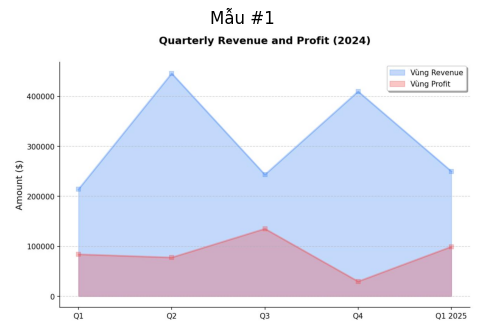

❓ Câu hỏi    : Từ Quý 1 đến Quý 4 năm hiện tại, doanh thu và lợi nhuận có xu hướng tăng hay giảm?
✅ Đáp án GT  : Tăng nhẹ rồi giảm sau Quý 3
🔮 Dự đoán B1 : Tăng


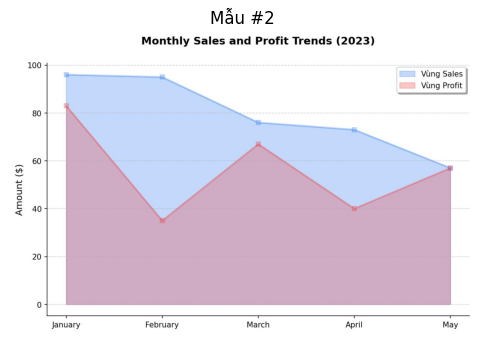

❓ Câu hỏi    : So sánh nửa đầu và nửa cuối năm, doanh thu và lợi nhuận có sự khác biệt gì?
✅ Đáp án GT  : Đầu năm tăng hơn cuối năm
🔮 Dự đoán B1 : Hạn doanh thu và lợi nhuận giảm, nhưng tỷ lệ giảm khác


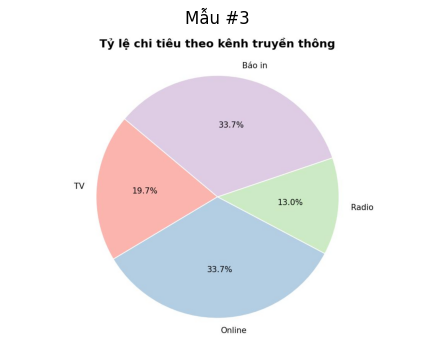

❓ Câu hỏi    : Trong các kênh truyền thông, kênh nào có chi tiêu cao nhất và kênh nào thấp nhất?
✅ Đáp án GT  : Kênh cao nhất là Online, kênh thấp nhất là Radio
🔮 Dự đoán B1 : Kênh truyền thông có chi tiêu cao nhất là báo chí,


In [ ]:
# ============================================================
# CELL 7 — Demo: Chạy thử 3 mẫu đầu tiên
# ============================================================
NUM_DEMO = 3  # Thay số này để xem thêm mẫu

for i in range(NUM_DEMO):
    item = dataset[i]
    image       = item['image']
    question    = item['question']
    ground_truth = item['answer']

    prediction = get_zero_shot_prediction(image, question)

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Mẫu #{i+1}", fontsize=12)
    plt.show()

    print(f"❓ Câu hỏi    : {question}")
    print(f"✅ Đáp án GT  : {ground_truth}")
    print(f"🔮 Dự đoán B1 : {prediction}")
    print("=" * 60)